# EDA — bank-marketing (henriqueyamahata)

A camada de entrada desta análise é `data/processed/bank_marketing.csv`, já sem `duration` (ver `data/kaggle/README.md` para a decisão de vazamento).

In [1]:
import pandas as pd; df = pd.read_csv("../data/processed/bank_marketing.csv"); df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


## Balanço do target

In [2]:
df["target"].value_counts(normalize=True)

target
0    0.887346
1    0.112654
Name: proportion, dtype: float64

## Valores ausentes

In [3]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
target            0
dtype: int64

## Distribuições numéricas

In [4]:
df.describe()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


Text(0.5, 1.0, 'Distribuição de idade')

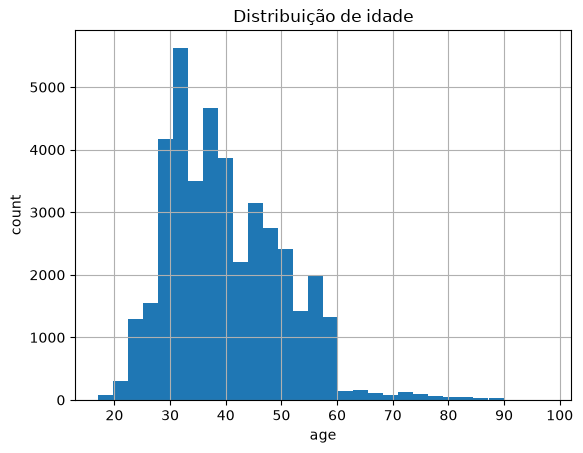

In [5]:
import matplotlib.pyplot as plt; df["age"].hist(bins=30); plt.xlabel("age"); plt.ylabel("count"); plt.title("Distribuição de idade")

## Distribuições categóricas principais

Text(0.5, 1.0, 'Distribuição de job')

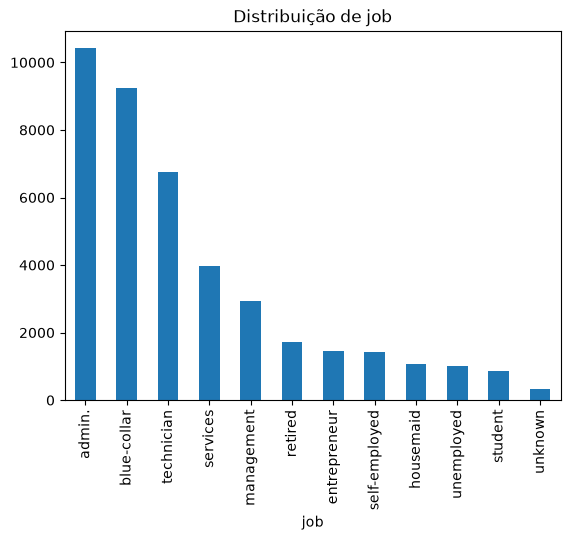

In [6]:
df["job"].value_counts().plot(kind="bar"); plt.title("Distribuição de job")

## Conclusões da qualidade dos dados

- **Volume e desbalanceamento do target:** o dataset processado tem 41.188 linhas e 21 colunas (20 features + `target`). O target é bastante desbalanceado — 88,7% "no" contra 11,3% "yes" (razão ~7,9:1) —, algo que a política de bandit precisa considerar ao lidar com a raridade da conversão.
- **"unknown" mascara ausência de dado:** não há nenhum valor nulo técnico (`isna().sum()` é zero em todas as colunas), mas 6 colunas categóricas usam a string `"unknown"` como sentinela de dado ausente — `default` se destaca com 20,9% de "unknown" (bem acima de `education` 4,2%, `housing`/`loan` 2,4%, `job` 0,8% e `marital` 0,2%).
- **`pdays` é um sentinela disfarçado de número:** 96,3% das linhas têm `pdays = 999` ("nunca contatado antes"), então essa coluna não deve ser tratada como uma escala numérica contínua sem antes isolar esse sentinela.
- **`campaign` é fortemente assimétrica à direita:** a mediana é de 2 contatos, mas o máximo chega a 56, com 157 linhas acima de 20 contatos — outliers de esforço de contato que merecem cap/winsorização antes de qualquer modelagem.
- **Arquivo real é a variante estendida (já documentada), e com duplicatas:** o arquivo baixado do Kaggle é `bank-additional-full.csv` (a variante estendida, com indicadores macroeconômicos como `emp.var.rate`, `cons.price.idx`, `euribor3m`), e não contém a coluna `balance`, presente apenas na variante clássica `bank-full.csv`; o dicionário de dados em `data/kaggle/README.md` já reflete esse schema real. Além disso, há 1.784 linhas totalmente duplicadas (~4,3% da base), provavelmente clientes com perfil e contexto macroeconômico idênticos — vale investigar antes do treinamento.
